In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pandas import set_option
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report

from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import seaborn as sns; sns.set() 

In [2]:
set_option("display.max_rows", 10)
pd.options.mode.chained_assignment = None

filename = 'data11tumors2.csv'
training_data = pd.read_csv(filename)
training_data

,Class,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D12524,D12525,D12526,D12527,D12528,D12529,D12530,D12531,D12532,D12533
0,7,153,228,32,30,-36,48,984,-19,537,...,100,30,83,28,57,106,128,5,74,-188
1,7,154,99,43,55,66,63,5051,-26,1001,...,27,43,90,30,82,485,896,-2,91,-78
2,7,84,85,19,28,-104,28,2387,-80,1131,...,-32,51,110,10,86,62,76,-47,92,-103
3,7,234,169,40,36,81,6,2657,-6,1214,...,43,52,82,12,135,60,69,22,89,-180
4,7,104,58,42,13,107,5,3562,18,1464,...,159,42,73,1,82,60,50,30,74,-198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,0,157,578,40,58,5,-49,57,-29,3306,...,4,45,64,37,169,91,180,-4,60,-142
170,0,286,882,110,-19,-142,-66,-5,23,2701,...,-91,130,137,-61,75,36,58,44,161,-433
171,0,579,667,55,-41,-98,-138,-164,-61,2812,...,-110,107,199,-60,59,8,77,-42,171,-371
172,0,252,582,88,3,44,-162,553,-150,2020,...,-66,92,-26,-44,148,43,73,0,201,-333


In [3]:
patterns_labels = ['T0','T1', 'T2','T3', 'T4','T5', 'T6','T7', 'T8','T9', 'T10']
correct_Pattern_labels = training_data['Class'].values
feature_vectors = training_data.drop(['Class'], axis=1)

In [4]:
correct_Pattern_labels

array([ 7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  1,  1,  1,  1,  1,  1,  1,
        1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  8,  8,  8,  8,  8,  8,  9,  9,
        9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10,  2, 10,
        4,  3,  0,  6,  0,  0,  3,  2,  9, 10,  7,  7,  2,  2,  5,  2,  0,
        9,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  9, 10,  9, 10, 10,  9,
       10,  2,  2,  2,  2,  2,  2,  2,  2,  2,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0], dtype=int64)

In [5]:
feature_vectors

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,D12524,D12525,D12526,D12527,D12528,D12529,D12530,D12531,D12532,D12533
0,153,228,32,30,-36,48,984,-19,537,1886,...,100,30,83,28,57,106,128,5,74,-188
1,154,99,43,55,66,63,5051,-26,1001,1315,...,27,43,90,30,82,485,896,-2,91,-78
2,84,85,19,28,-104,28,2387,-80,1131,2457,...,-32,51,110,10,86,62,76,-47,92,-103
3,234,169,40,36,81,6,2657,-6,1214,1944,...,43,52,82,12,135,60,69,22,89,-180
4,104,58,42,13,107,5,3562,18,1464,1385,...,159,42,73,1,82,60,50,30,74,-198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,157,578,40,58,5,-49,57,-29,3306,707,...,4,45,64,37,169,91,180,-4,60,-142
170,286,882,110,-19,-142,-66,-5,23,2701,1360,...,-91,130,137,-61,75,36,58,44,161,-433
171,579,667,55,-41,-98,-138,-164,-61,2812,5167,...,-110,107,199,-60,59,8,77,-42,171,-371
172,252,582,88,3,44,-162,553,-150,2020,6945,...,-66,92,-26,-44,148,43,73,0,201,-333


In [6]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(feature_vectors)
feature_vectors = scaler.transform(feature_vectors)

In [7]:
from sklearn.cross_validation import train_test_split
validation_size = 0.2
seed = 0
X_train, X_validation, Y_train, Y_validation = train_test_split(feature_vectors, correct_Pattern_labels, test_size=validation_size, random_state=seed)

C:\Users\tommy\Anaconda3\lib\site-packages\sklearn\cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [8]:
seed = 42
scoring = 'accuracy'

models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC()))
models.append(('MLP', MLPClassifier()))
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, random_state=seed)
    cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# We can also create a plot of the model evaluation results and compare the spread and the mean accuracy of each model. There is a population of accuracy measures for each algorithm because each algorithm was evaluated 10 times (10 fold cross validation).


LR: 0.935714 (0.067386)


C:\Users\tommy\Anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:388: UserWarning: Variables are collinear.
  warnings.warn("Variables are collinear.")
C:\Users\tommy\Anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:388: UserWarning: Variables are collinear.
  warnings.warn("Variables are collinear.")
C:\Users\tommy\Anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:388: UserWarning: Variables are collinear.
  warnings.warn("Variables are collinear.")
C:\Users\tommy\Anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:388: UserWarning: Variables are collinear.
  warnings.warn("Variables are collinear.")
C:\Users\tommy\Anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:388: UserWarning: Variables are collinear.
  warnings.warn("Variables are collinear.")
C:\Users\tommy\Anaconda3\lib\site-packages\sklearn\discriminant_analysis.py:442: UserWarning: The priors do not sum to 1. Renormalizing
  UserWarning)
C:\Users\tommy\Anaconda3\lib\site-

LDA: 0.814286 (0.091473)
KNN: 0.682967 (0.108314)
SVM: 0.677473 (0.145952)
MLP: 0.784615 (0.100289)


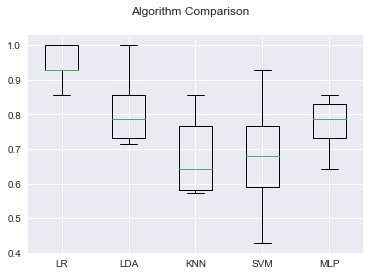

In [9]:
# Compare Algorithms Accuracy
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(kernel = 'rbf', C = 10 )
KNN.fit(X_train, Y_train)
predictions = KNN.predict(X_validation)

TypeError: _init_params() got an unexpected keyword argument 'kernel'

In [ ]:
def accuracy(conf):
    total_correct = 0.
    nb_classes = conf.shape[0]
    for i in np.arange(0,nb_classes):
        total_correct += conf[i][i]
    acc = total_correct/sum(sum(conf))
    return acc

def resultados(Y_validation,predictions):
    conf = confusion_matrix(Y_validation, predictions)
    print 'Flow Pattern classification accuracy = %f' % accuracy(conf)

    print 'Accuracy:', accuracy_score(Y_validation, predictions)
    print 'F1 score:', f1_score(Y_validation, predictions,average='weighted')
    print 'Recall:', recall_score(Y_validation, predictions,
                              average='weighted')
    print 'Precision:', precision_score(Y_validation, predictions,
                                    average='weighted')
    print '\n clasification report:\n', classification_report(Y_validation, predictions)
    print '\n confussion matrix:\n',confusion_matrix(Y_validation, predictions)

In [ ]:
resultados(Y_validation,predictions)

In [ ]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X_train, Y_train)
predictions = LR.predict(X_validation)

In [ ]:
resultados(Y_validation,predictions)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
LDA = LinearDiscriminantAnalysis()
LDA.fit(X_train, Y_train)
predictions = LDA.predict(X_validation)

In [ ]:
resultados(Y_validation,predictions)

In [ ]:
from sklearn.svm import SVC
SVM = SVC(kernel = 'rbf', C = 10 )
SVM.fit(X_train, Y_train)
predictions = SVM.predict(X_validation)

In [ ]:
resultados(Y_validation,predictions)

In [ ]:
MLP = MLPClassifier()
MLP.fit(X_train, Y_train)
predictions = MLP.predict(X_validation)

In [ ]:
resultados(Y_validation,predictions)

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier([250,250,250], activation = 'relu', solver = 'adam')
mlp.fit(X_train, y_train)
print('acc on train dataset: {:.3f}'.format(mlp.score(X_train,y_train)))
print('acc on test dataset: {:.3f}'.format(mlp.score(X_test,y_test)))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit(X_train).transform(X_train)
x_test_scaled = scaler.fit(X_test).transform(X_test)

mlp = MLPClassifier(max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

print('acc on train dataset: {:.3f}'.format(mlp.score(X_train_scaled,y_train)))
print('acc on test dataset: {:.3f}'.format(mlp.score(X_test_scaled,y_test)))